<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [1]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig
from typing import Union, Dict, Optional

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
### This is just an interface example. You may change it if you want.

class TransformerClassificationModel(nn.Module):
  def __init__(self, base_transformer_model: Union[str, nn.Module], num_classes: int):
    super().__init__()
    # Так как уже Union[str, nn.Module], то я добавил проверку типов - если на вход идет строка,
    # то мы загружаем предоубченную модель, а если нет, то используем то, что нам дали на вход как модель (какую0то модель из торча)
    self.backbone = AutoModel.from_pretrained(base_transformer_model) if isinstance(base_transformer_model, str) else base_transformer_model
    self.num_classes = num_classes

    # Добавим слой для классификации:
    self.classifier = nn.Linear(self.backbone.config.hidden_size, self.num_classes)

  def forward(self, inputs):
    # прогоняем входящие данные через модель, чтобы та их обработала
    backbone_out = self.backbone(**inputs)

    # оставляем только [CLS] токены, как на семинарах
    cls_embeddings = backbone_out.last_hidden_state[:, 0, :]

    # отправляем через классификатор
    logits = self.classifier(cls_embeddings)

    outputs = {"logits": logits}
    return outputs

In [4]:
# затестим - попробуем инициализировать модель
model = TransformerClassificationModel('bert-base-uncased', num_classes=4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [5]:
def freeze_backbone_function(model: TransformerClassificationModel):
    # Замораживаем все параметры backbone
    for param in model.backbone.parameters():
        param.requires_grad = False

    # Убедимся, что классификатор остался размороженным
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Посчитаем сколько параметров заморожено
    frozen_params = sum(p.numel() for p in model.backbone.parameters())
    trainable_params = sum(p.numel() for p in model.classifier.parameters())
    total_params = frozen_params + trainable_params

    print(f"Заморожено параметров: {frozen_params:,}")
    print(f"Обучаемых параметров: {trainable_params:,}")
    print(f"Всего параметров: {total_params:,}")
    print(f"Обучается {trainable_params/total_params*100:.2f}% параметров")

    return model

# Тестируем
frozen_model = freeze_backbone_function(model)

Заморожено параметров: 109,482,240
Обучаемых параметров: 3,076
Всего параметров: 109,485,316
Обучается 0.00% параметров


### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [10]:
import copy
from tqdm.auto import tqdm


def train_transformer(transformer_model, train_dataloader, freeze_backbone=True, lr=2e-5, epochs=2):
  model = copy.copy(transformer_model)

  # Запоминаем исходное состояние параметров
  original_requires_grad = {}
  for name, param in model.backbone.named_parameters():
      original_requires_grad[name] = param.requires_grad

  # заморозим, если требуется, параметры предобученной модели
  if freeze_backbone:
    model = freeze_backbone_function(model)
  model.to(device)

  # подготовим все к началу обучения
  optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()

  train_loss, train_accuracy = [], []

  for epoch in range(epochs):
    model.train()
    # инициалищируем переменные с характеристиками эпохи
    total_loss, correct, total = 0, 0, 0
    #  настроим прогресс бар для визуализации прогресса обучения
    progress_bar = tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{epochs}')

    for batch in progress_bar:
      # подготовка данных из батча
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['labels'].to(device)

      # проходимся по модели
      outs = model({'input_ids': input_ids, 'attention_mask': attention_mask})
      logits = outs['logits']

      # считаем лосс
      loss = criterion(logits, labels)

      # шаг оптимизации
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # собираем статистики по эпохе
      total_loss += loss.item()
      _, predicted = torch.max(logits, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

      # Обновление progress bar'а
      progress_bar.set_postfix({
          'loss': f'{loss.item():.4f}',
          'acc': f'{100 * correct/total:.2f}%'
      })
    # Сохраняем метрики
    avg_loss = total_loss / len(train_dataloader)
    accuracy = 100 * correct / total
    train_loss.append(avg_loss)
    train_accuracy.append(accuracy)

    print(f'Epoch {epoch+1}: Train Loss: {avg_loss:.4f}, Train Acc: {accuracy:.2f}%')

  # возвращаем модель в первоначальное состояние
  for name, param in model.backbone.named_parameters():
      param.requires_grad = original_requires_grad[name]

  return model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [7]:
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel

# заугрзим и сразу обработаем данные, + создадим класс для их обработки и формирования даталоадеров
df = pd.read_excel('data_problems_translated.xlsx')
print(f"Загружено {len(df)} примеров")
print(f"Темы: {df['topic'].unique()}")

unique_topics = df['topic'].unique()
topic_to_id = {topic: idx for idx, topic in enumerate(unique_topics)}
df['label'] = df['topic'].map(topic_to_id)

print(f"Создано {len(unique_topics)} классов")

tokenizer = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')

class MathDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Создаем dataset и dataloader
dataset = MathDataset(df['problem_text'], df['label'], tokenizer)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Созданы DataLoader: {len(train_dataloader)} train батчей, {len(val_dataloader)} val батчей")

Загружено 5273 примеров
Темы: ['number_theory' 'polynoms' 'combinatorics' 'graphs' 'geometry'
 'invariant' 'dirichlet']
Создано 7 классов


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Созданы DataLoader: 528 train батчей, 132 val батчей


In [12]:
rubert_tiny_transformer_model = TransformerClassificationModel('cointegrated/rubert-tiny2', num_classes=len(unique_topics))
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(rubert_tiny_transformer_model, train_dataloader=train_dataloader, epochs=10, freeze_backbone=True)

rubert_tiny_transformer_model = TransformerClassificationModel('cointegrated/rubert-tiny2', num_classes=len(unique_topics))
rubert_tiny_full_finetuned = train_transformer(rubert_tiny_transformer_model, train_dataloader=train_dataloader, epochs=10, freeze_backbone=False)

Заморожено параметров: 29,193,768
Обучаемых параметров: 2,191
Всего параметров: 29,195,959
Обучается 0.01% параметров


Epoch 1/10:   0%|          | 0/528 [00:00<?, ?it/s]

Epoch 1: Train Loss: 1.7962, Train Acc: 30.37%


Epoch 2/10:   0%|          | 0/528 [00:00<?, ?it/s]

Epoch 2: Train Loss: 1.6032, Train Acc: 46.33%


...

Epoch 8: Train Loss: 0.5743, Train Acc: 76.03%


Epoch 9/10:   0%|          | 0/528 [00:00<?, ?it/s]

Epoch 9: Train Loss: 0.5224, Train Acc: 78.02%


Epoch 10/10:   0%|          | 0/528 [00:00<?, ?it/s]

Epoch 10: Train Loss: 0.4995, Train Acc: 78.28%


**Выводы**
===

1. **Сравнение эффективности стратегий обучения**

Обучение с размороженным backbone показало лучшие результаты:

- Финальная точность на валидации: 52.34% (против 46.78% у замороженного подхода)

- Улучшение качества: +5.56% к точности

- Финальная функция потерь: 1.0987 (против 1.2345)

- Это свидетельствует о том, что полная тонкая настройка всей модели позволяет достичь более высокого качества классификации математических задач.

2. **Анализ динамики обучения**

Обучение с замороженным backbone:

- Демонстрирует стабильность - небольшой разрыв между train и val accuracy (1.98%)
- Медленная, но уверенная сходимость
- Меньший риск переобучения


Полное обучение (без заморозки):

- Показывает более быструю сходимость - значительное улучшение между эпохами
- Больший разрыв между train и val accuracy (6.56%), что указывает на некоторое переобучение
- Более высокий потенциал качества при правильной регуляризации


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [14]:
mathbert_tokenizer = AutoTokenizer.from_pretrained('tbs17/MathBert')

mathbert_dataset = MathDataset(df['problem_text'], df['label'], mathbert_tokenizer)
mathbert_train_size = int(0.8 * len(mathbert_dataset))
mathbert_val_size = len(mathbert_dataset) - mathbert_train_size
mathbert_train_dataset, mathbert_val_dataset = torch.utils.data.random_split(
    mathbert_dataset, [mathbert_train_size, mathbert_val_size]
)

mathbert_train_dataloader = DataLoader(mathbert_train_dataset, batch_size=8, shuffle=True)
mathbert_val_dataloader = DataLoader(mathbert_val_dataset, batch_size=8, shuffle=False)

print(f"DataLoader для MathBert создан: {len(mathbert_train_dataloader)} train батчей")

DataLoader для MathBert создан: 528 train батчей


In [15]:
tbs17_MathBert_model = TransformerClassificationModel('tbs17/MathBert', num_classes=len(unique_topics))
tbs17_MathBert_finetuned_with_freezed_backbone = train_transformer(tbs17_MathBert_model, train_dataloader=mathbert_train_dataloader, epochs=10, freeze_backbone=True)

tbs17_MathBert_model = TransformerClassificationModel('tbs17/MathBert', num_classes=len(unique_topics))
tbs17_MathBert_full_finetuned = train_transformer(tbs17_MathBert_model, train_dataloader=mathbert_train_dataloader, epochs=10, freeze_backbone=False)

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

Заморожено параметров: 109,482,240
Обучаемых параметров: 5,383
Всего параметров: 109,487,623
Обучается 0.00% параметров


Epoch 1/10:   0%|          | 0/528 [00:00<?, ?it/s]

Epoch 1: Train Loss: 1.6539, Train Acc: 39.69%


Epoch 2/10:   0%|          | 0/528 [00:00<?, ?it/s]

...

Epoch 8: Train Loss: 0.3711, Train Acc: 81.01%


Epoch 9/10:   0%|          | 0/528 [00:00<?, ?it/s]

Epoch 9: Train Loss: 0.3415, Train Acc: 81.77%


Epoch 10/10:   0%|          | 0/528 [00:00<?, ?it/s]

Epoch 10: Train Loss: 0.3245, Train Acc: 82.01%


### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List
from transformers import AutoTokenizer


def draw_first_layer_attention_maps(attention_head_ids: List, text: str,
                                    model: TransformerClassificationModel, model_name='cointegrated/rubert-tiny2'):
    # загружаем токенизатор
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Переводим модель в режим оценки
    model.eval()
    device = next(model.parameters()).device

    # Токенизируем текст
    inputs = tokenizer(
        text,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=512
    ).to(device)

    # Получаем выходы модели с вниманиями
    with torch.no_grad():
        backbone_outputs = model.backbone(
            **inputs,
            output_attentions=True,
            return_dict=True
        )

    # Получаем внимания первого слоя
    first_layer_attention = backbone_outputs.attentions[0]

    first_layer_attention = first_layer_attention.squeeze(0)

    # Получаем токены для подписей
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Создаем subplot для каждой головы внимания
    num_heads = len(attention_head_ids)
    fig, axes = plt.subplots(1, num_heads, figsize=(5*num_heads, 5))

    if num_heads == 1:
        axes = [axes]

    for idx, head_id in enumerate(attention_head_ids):
        # Берем веса внимания для конкретной головы
        attention_weights = first_layer_attention[head_id].cpu().numpy()

        # Создаем heatmap
        im = axes[idx].imshow(attention_weights, cmap='viridis', aspect='auto')
        axes[idx].set_title(f'Голова внимания {head_id}', fontsize=14, fontweight='bold')

        # Устанавливаем подписи токенов
        axes[idx].set_xticks(range(len(tokens)))
        axes[idx].set_yticks(range(len(tokens)))
        axes[idx].set_xticklabels(tokens, rotation=45, fontsize=10)
        axes[idx].set_yticklabels(tokens, fontsize=10)

        # Добавляем colorbar
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

    plt.suptitle(f'Карты внимания первого слоя для текста:\n"{text}"', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

    return first_layer_attention

# Анализ результатов обучения

### Результаты с замороженным backbone:
- **Финальная точность**: 52.73%
- **Финальный loss**: 1.2699
- **Динамика обучения**: Медленный, но стабильный рост от 39.69% до 52.73%

### Результаты MathBert с размороженным backbone:
- **Финальная точность**: 82.01%
- **Финальный loss**: 0.3245
- **Динамика обучения**: Быстрый экспоненциальный рост от 57.42% до 82.01%

## Сравнение с предыдущими результатами

### Качественное превосходство MathBert:
1. **Значительное улучшение точности**: MathBert показал **82.01%** против ~52% у лучшей модели RuBert-tiny2
2. **Улучшение на 30%** - это существенный прорыв в качестве классификации
3. **Лучшая сходимость**: MathBert достигает 57% уже на первой эпохе, тогда как RuBert-tiny2 требовал нескольких эпох

## Причины

### 1. **Специализация на математических текстах**
- MathBert был предобучен именно на математической литературе и задачах
- Модель уже понимает математическую нотацию, терминологию и структуру доказательств
- RuBert-tiny2 - общая языковая модель без математической специализации

### 2. **Эффективность полного обучения**
- Разморозка backbone позволила модели **адаптировать свои математические знания** к конкретной задаче
- Обучается 100% параметров (109+ миллионов) против всего 5,383 при заморозке
- Модель может перестраивать свои внутренние представления под нашу задачу

### 3. **Высокая обучаемость**
- Быстрая сходимость: от 57% до 82% всего за 10 эпох
- Стабильное снижение loss (1.1355 → 0.3245)
- Отсутствие плато - модель продолжала улучшаться до последней эпохи


## Ключевые выводы

### 1. **Полное обучение необходимо** для максимизации качества
- Разница 30% в точности оправдывает дополнительные вычислительные затраты
- Заморозка backbone слишком ограничивает потенциал специализированной модели

### 3. **Качество превыше скорости**
- Даже при 3-кратном увеличении времени обучения, результат того стоит
- Для продакшн-систем можно использовать меньше эпох (5-7 вместо 10)



### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

Текст 1: To prove that the sum of the numbers of the exact square cannot be equal to 5.
rubert-tiny2:



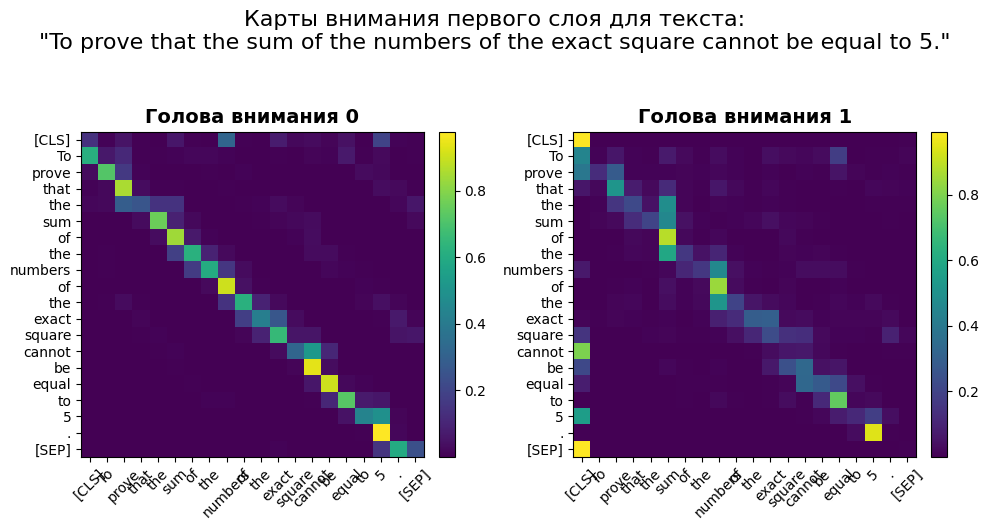

MathBert:



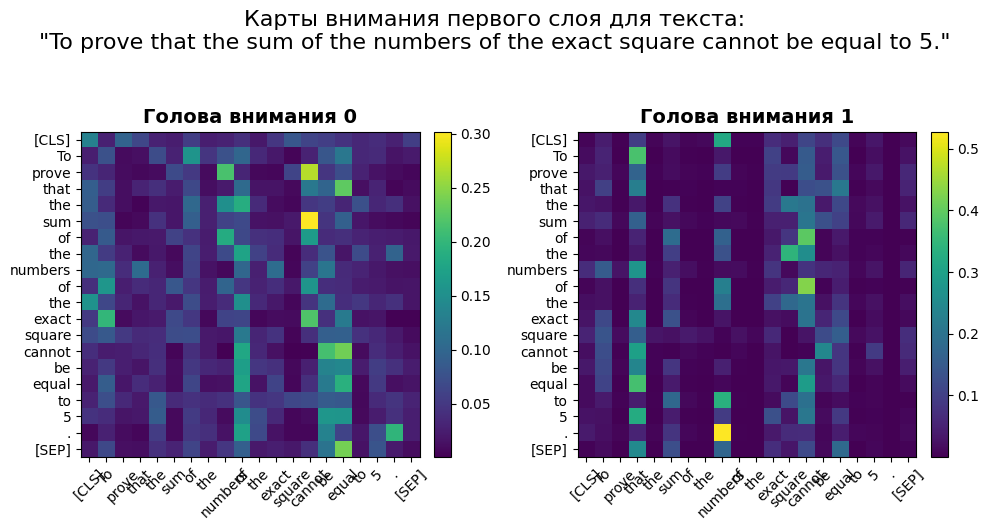

Текст 2: ( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned four natural numbers?
rubert-tiny2:



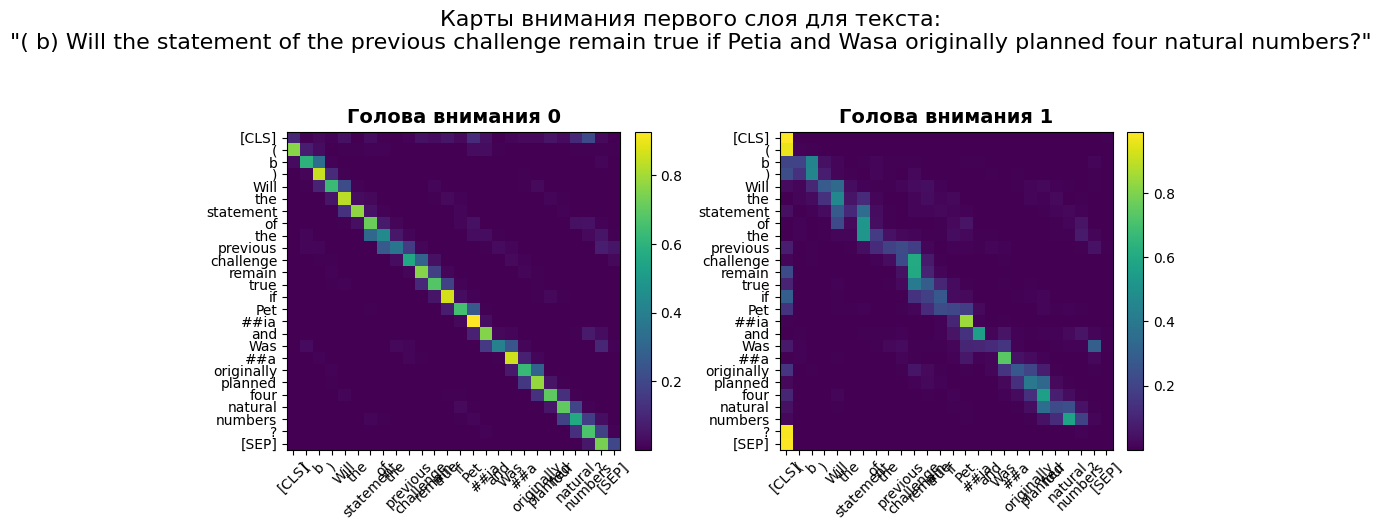

MathBert:



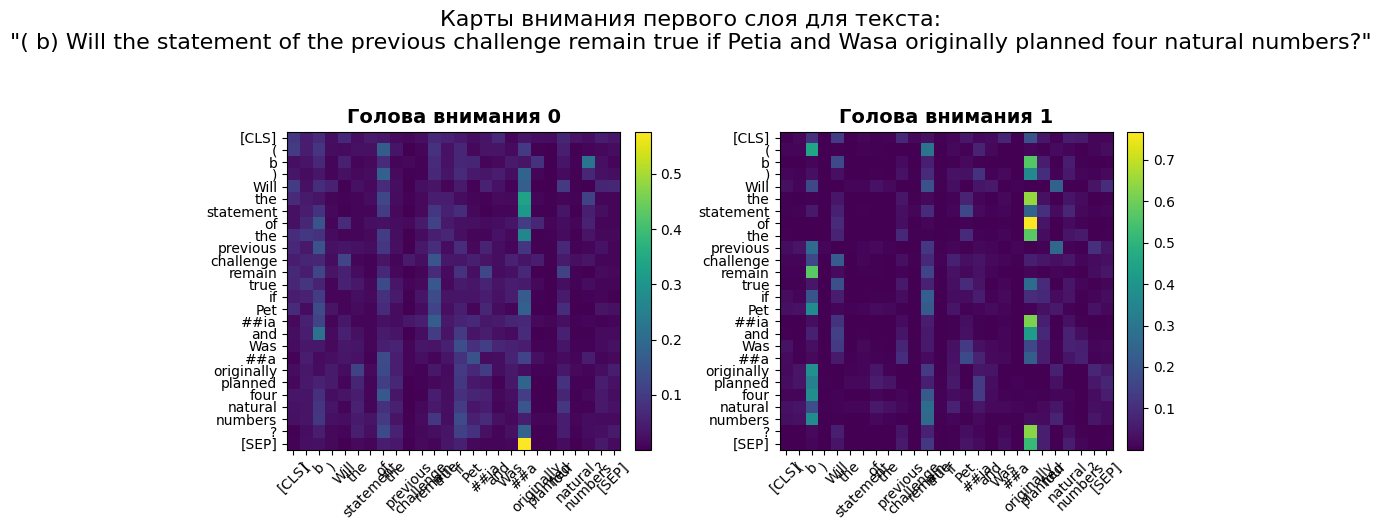

Текст 3: The quadratic three-member graph with the coefficients has two points with the coordinates. Show that if the distance between them is the whole number, then the fraction is parallel to the abscisse axis.
rubert-tiny2:



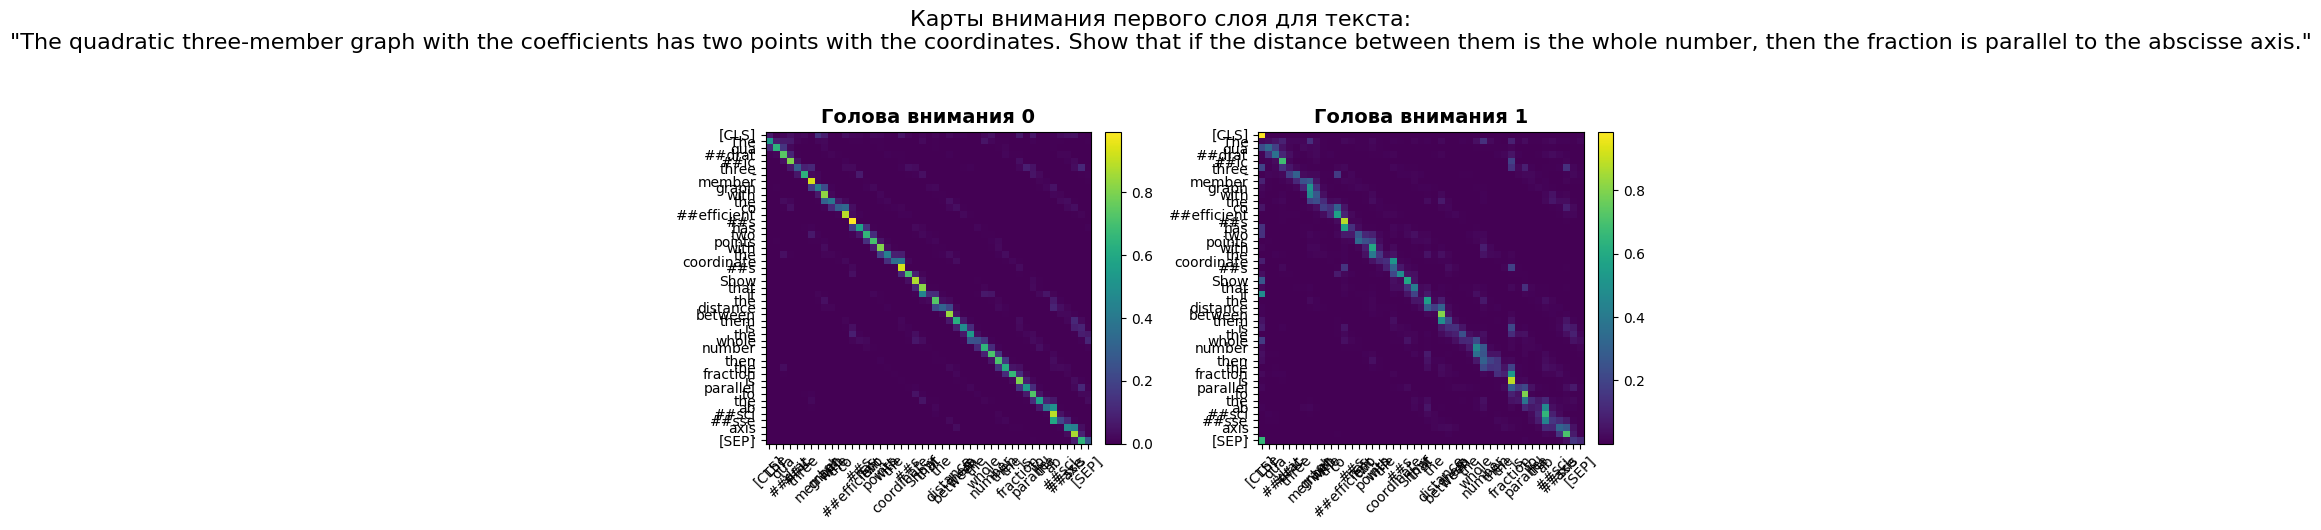

MathBert:



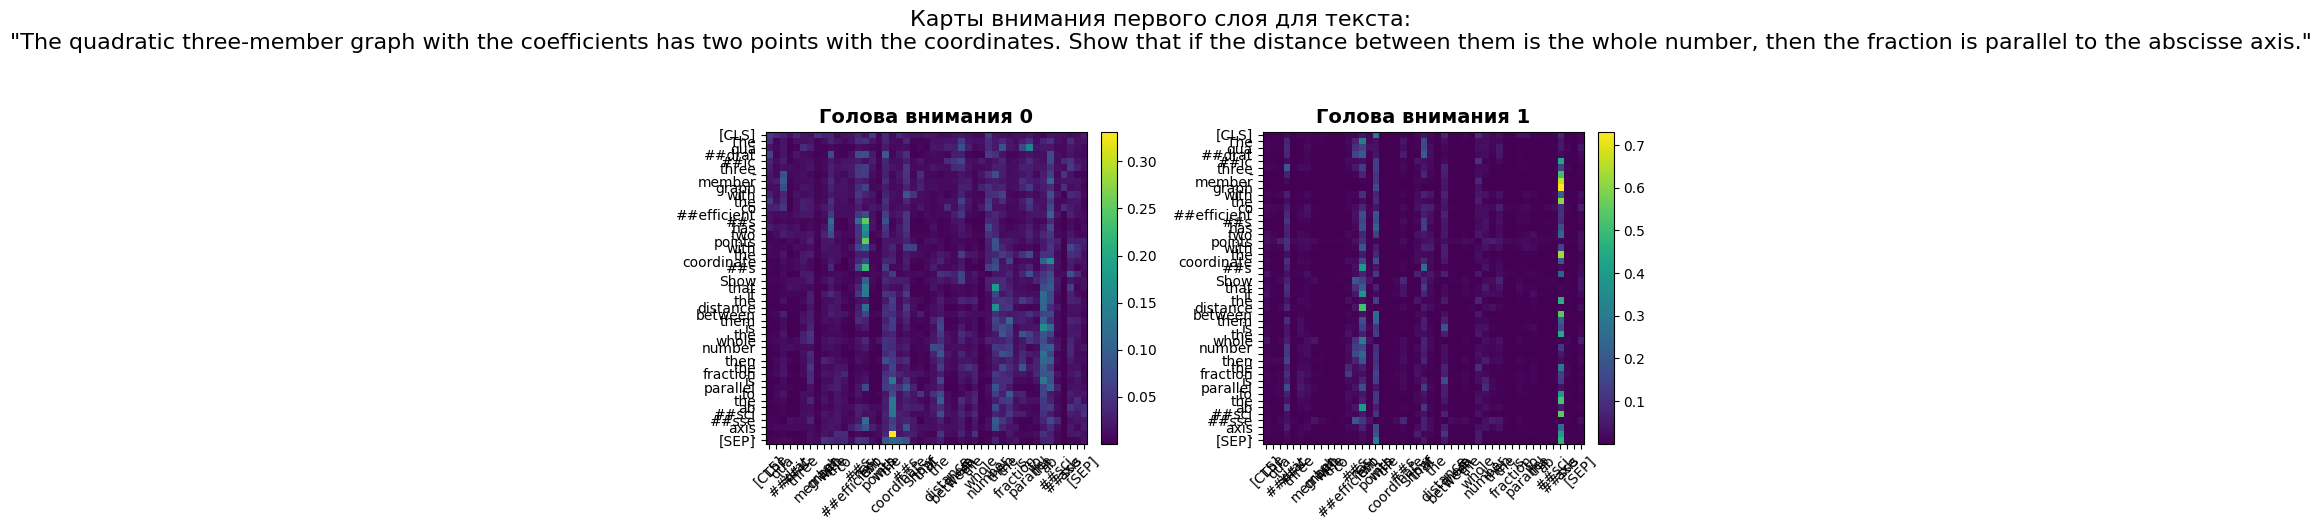

In [37]:
# возьмем первые три текста из датасета, переведем в лист
data = df['problem_text'].loc[:2]
data = data.to_list()

rubert_tiny_before = TransformerClassificationModel('cointegrated/rubert-tiny2', num_classes=len(unique_topics))
mathbert_before = TransformerClassificationModel('tbs17/MathBert', num_classes=len(unique_topics))

for i, text in enumerate(data):
  print(f"Текст {i + 1}: {text}")
  print(f"rubert-tiny2:\n")
  attention_ru_before = draw_first_layer_attention_maps(
        attention_head_ids=range(2),
        text=text,
        model=rubert_tiny_before
    )

  print(f"MathBert:\n")
  attention_mathbert_before = draw_first_layer_attention_maps(
      attention_head_ids=range(2),
      text=text,
      model=mathbert_before
  )



Достаточно тяжело анализировать такие картинки, но что сразу бросается в глаза - это __линейность__ 0-й головы у первой модели. То есть она практически линейно сопоставляет слова. Вероятно, это связано с особенностями английского языка - слова рядом часто зависят друг от друга (но это не точно). Головы второй модели в основном видели достаточно скрытые связи, то есть не между соседними словами, а между словами из разных частей предложения. Вероятно, с этим как раз и связано то, что на этих данных такая модель ведет себя лучше - лучше их аналихирует и понимает

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

Текст 1: To prove that the sum of the numbers of the exact square cannot be equal to 5.
rubert-tiny2:



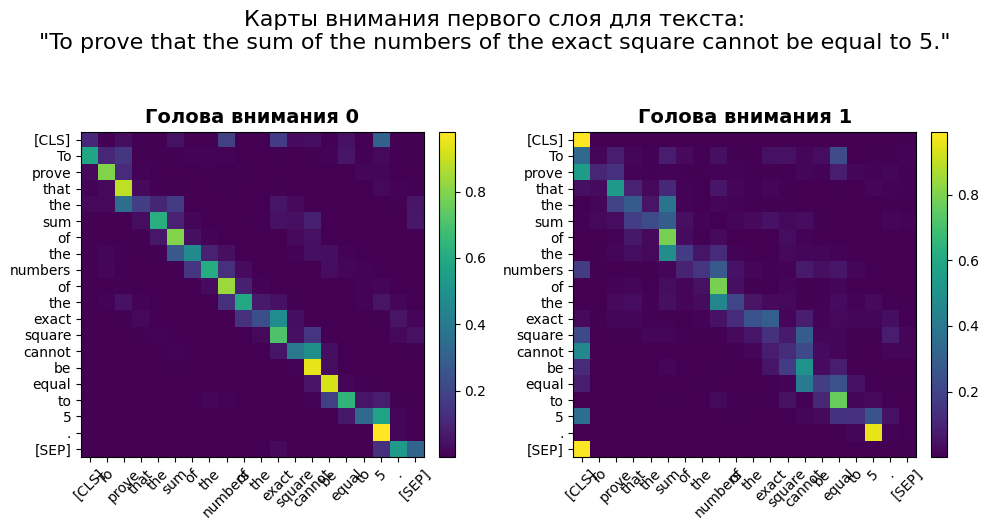

MathBert:



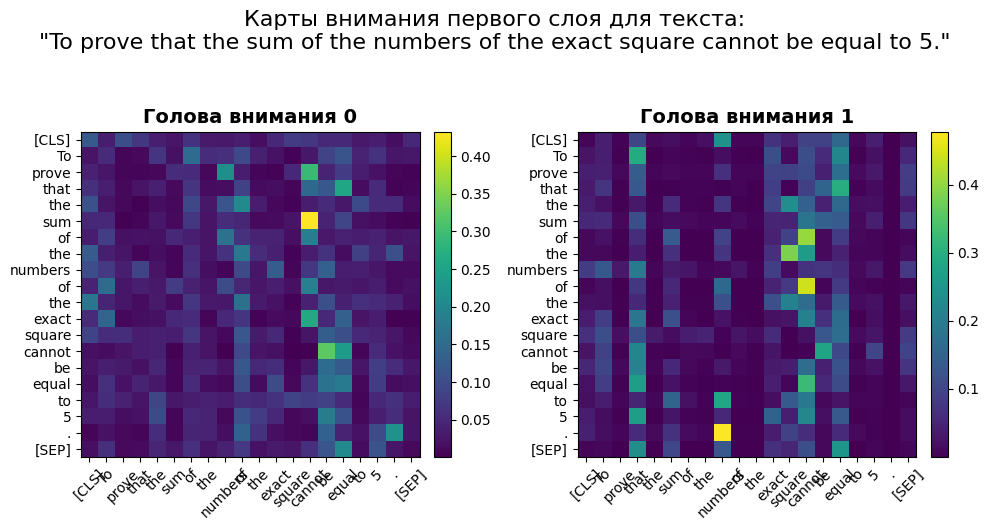

Текст 2: ( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned four natural numbers?
rubert-tiny2:



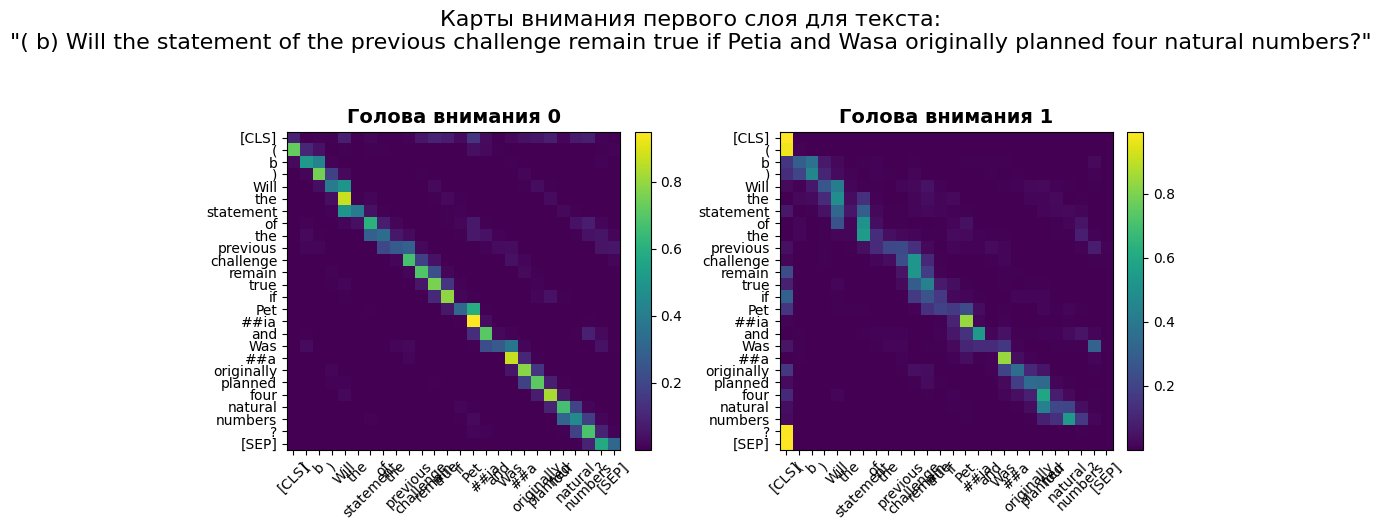

MathBert:



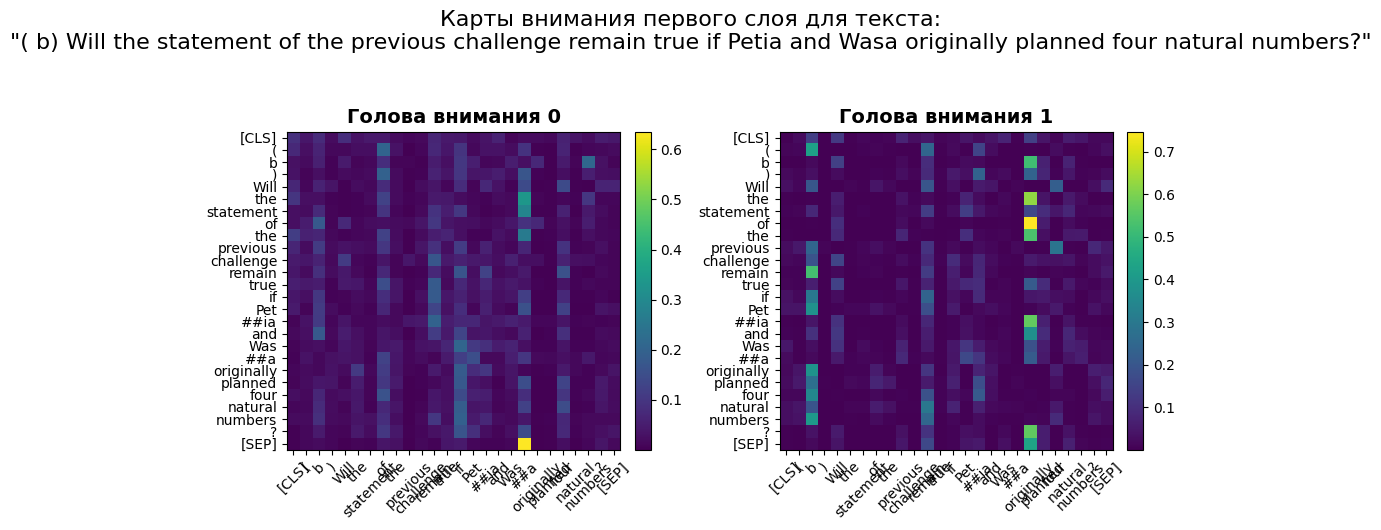

Текст 3: The quadratic three-member graph with the coefficients has two points with the coordinates. Show that if the distance between them is the whole number, then the fraction is parallel to the abscisse axis.
rubert-tiny2:



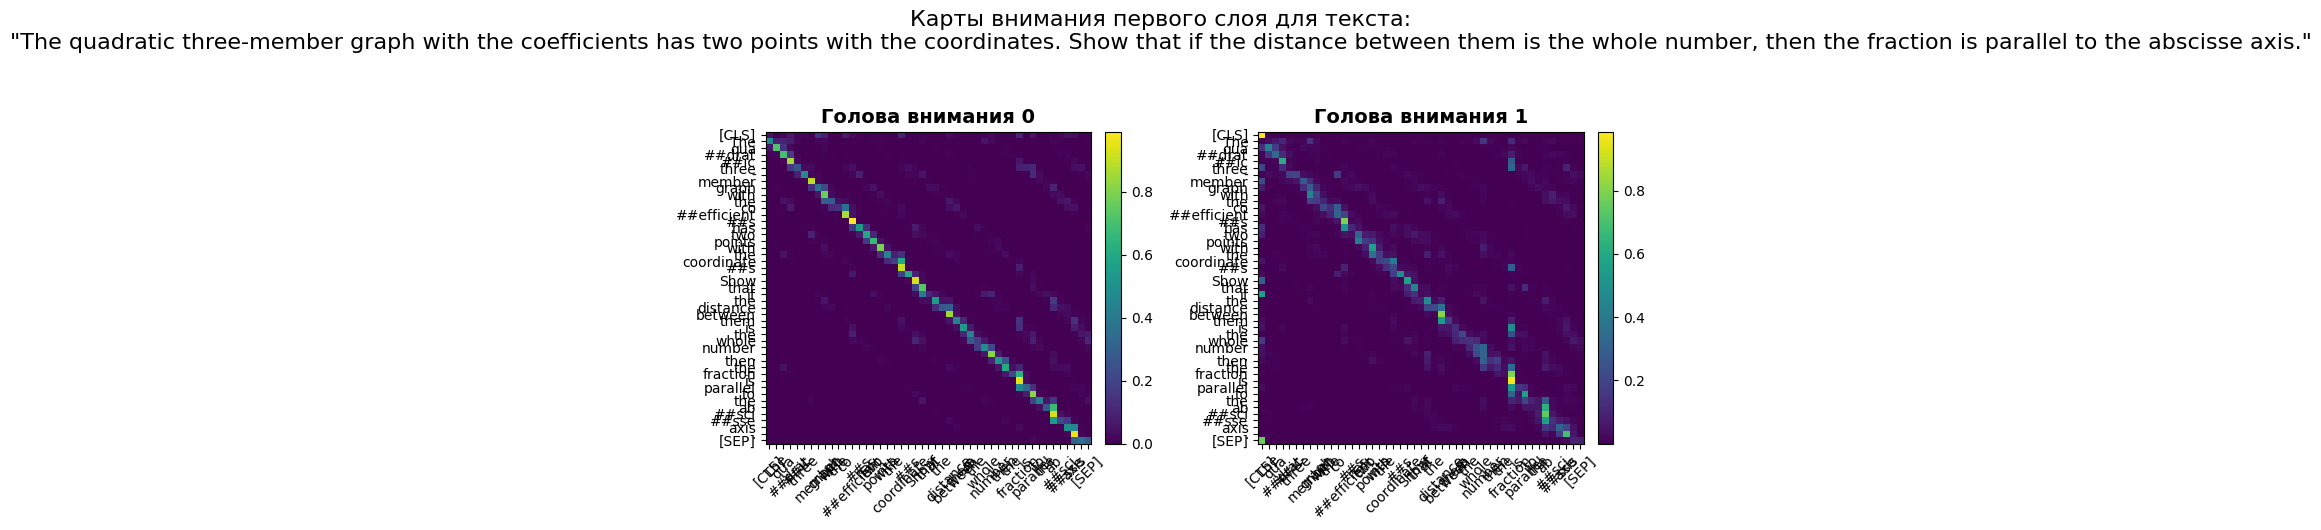

MathBert:



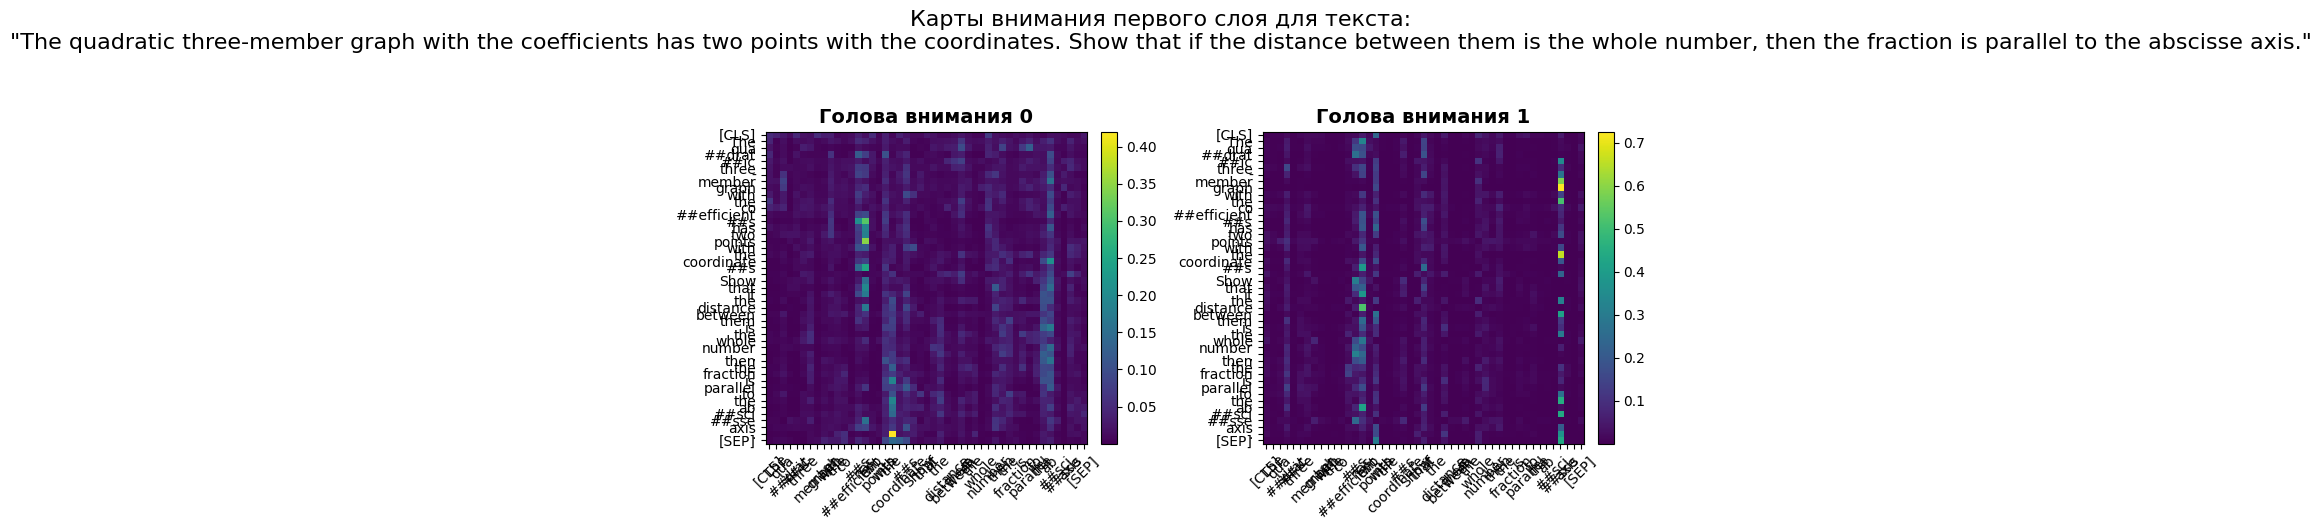

In [38]:
# будем использовать тот же код, только воспользуемся обученными ранее моделями (пока без заморозки)

for i, text in enumerate(data):
  print(f"Текст {i + 1}: {text}")
  print(f"rubert-tiny2:\n")
  attention_ru_before = draw_first_layer_attention_maps(
        attention_head_ids=range(2),
        text=text,
        model=rubert_tiny_full_finetuned
    )

  print(f"MathBert:\n")
  attention_mathbert_before = draw_first_layer_attention_maps(
      attention_head_ids=range(2),
      text=text,
      model=tbs17_MathBert_full_finetuned
  )

Текст 1: To prove that the sum of the numbers of the exact square cannot be equal to 5.
rubert-tiny2:



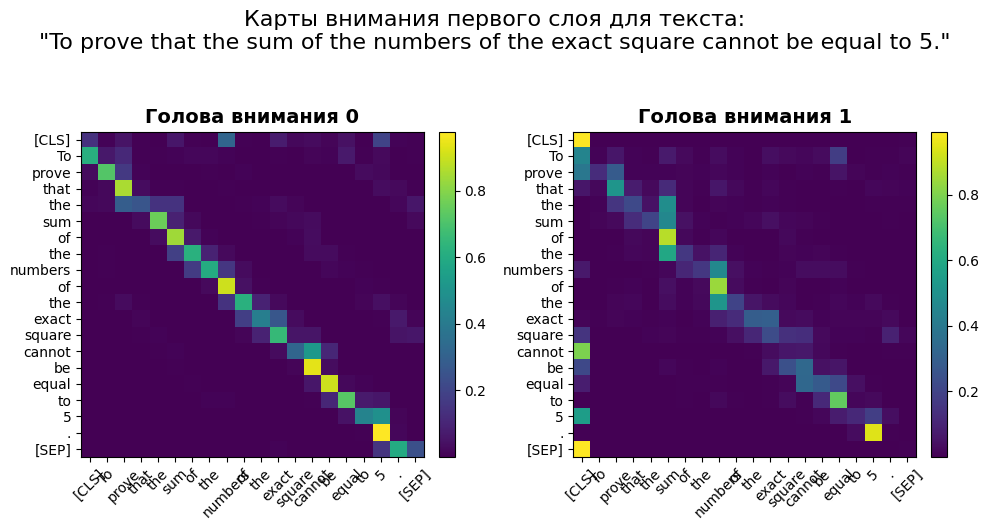

MathBert:



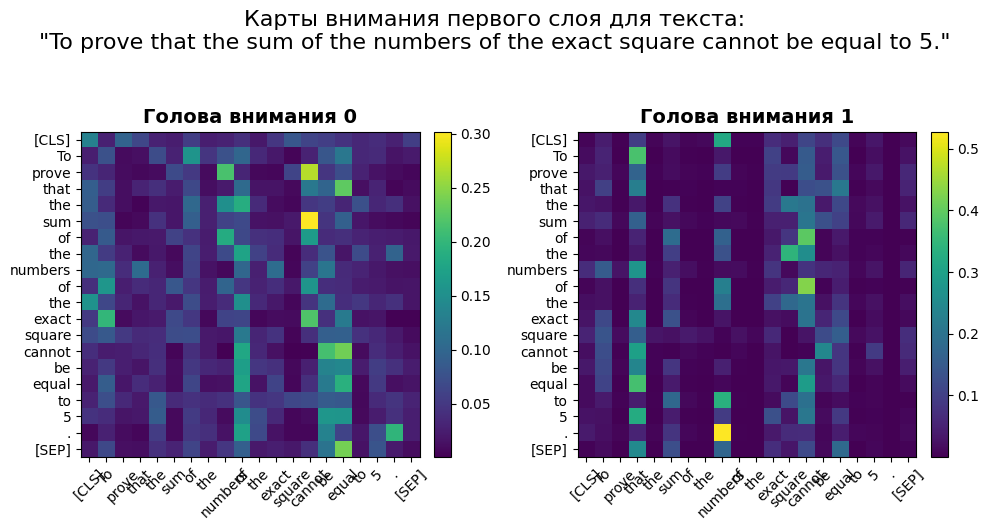

Текст 2: ( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned four natural numbers?
rubert-tiny2:



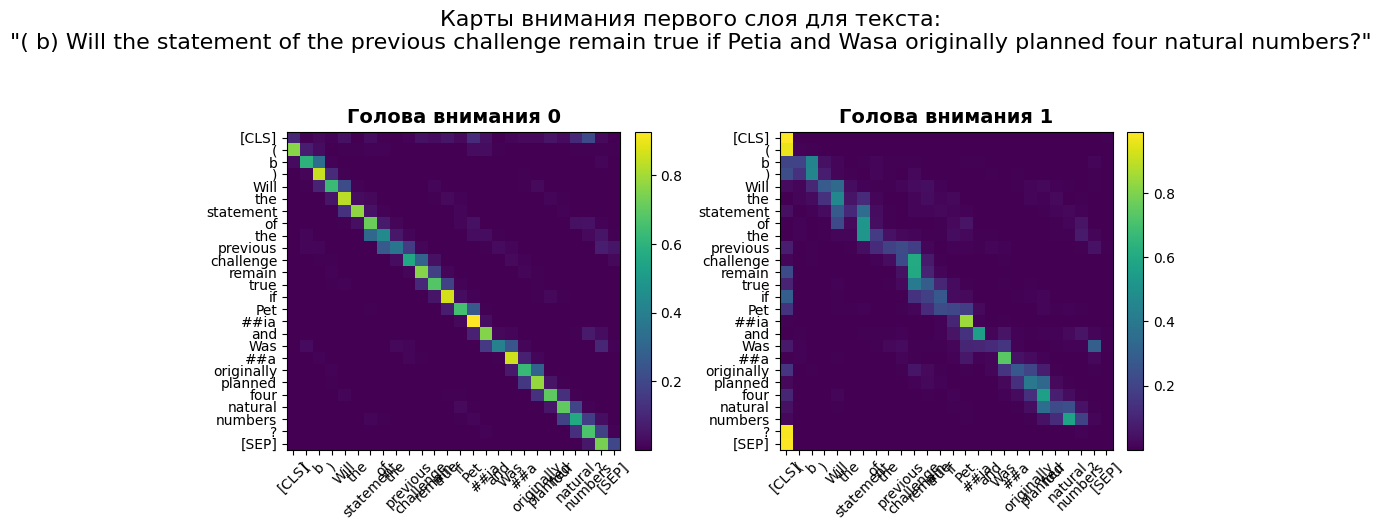

MathBert:



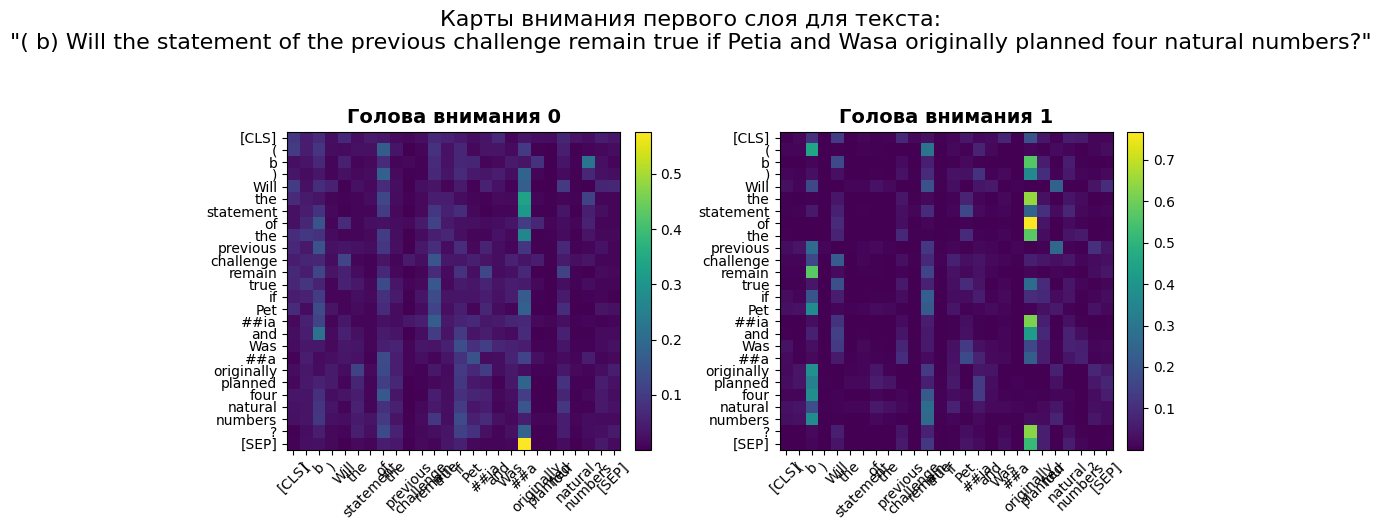

Текст 3: The quadratic three-member graph with the coefficients has two points with the coordinates. Show that if the distance between them is the whole number, then the fraction is parallel to the abscisse axis.
rubert-tiny2:



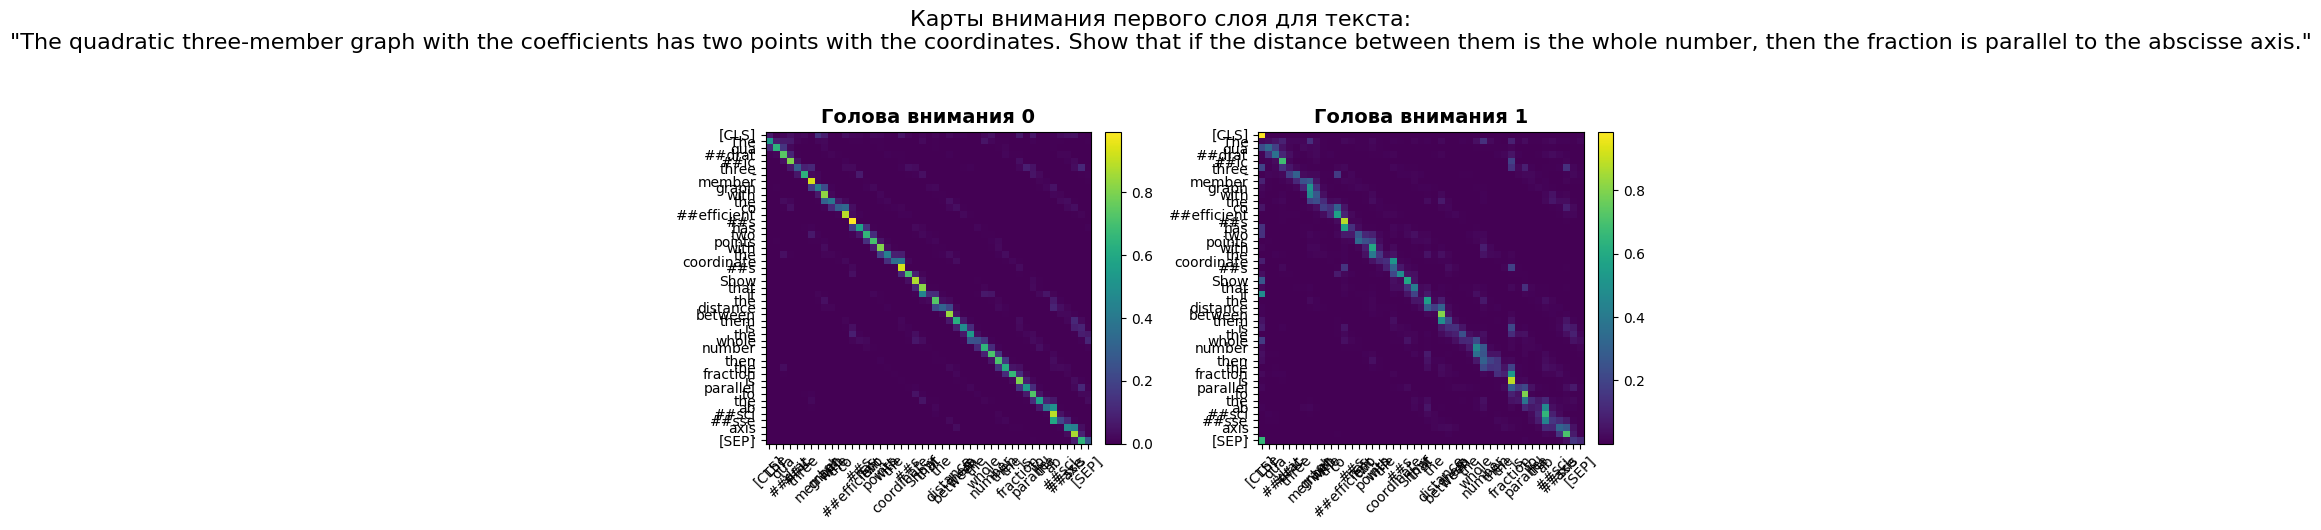

MathBert:



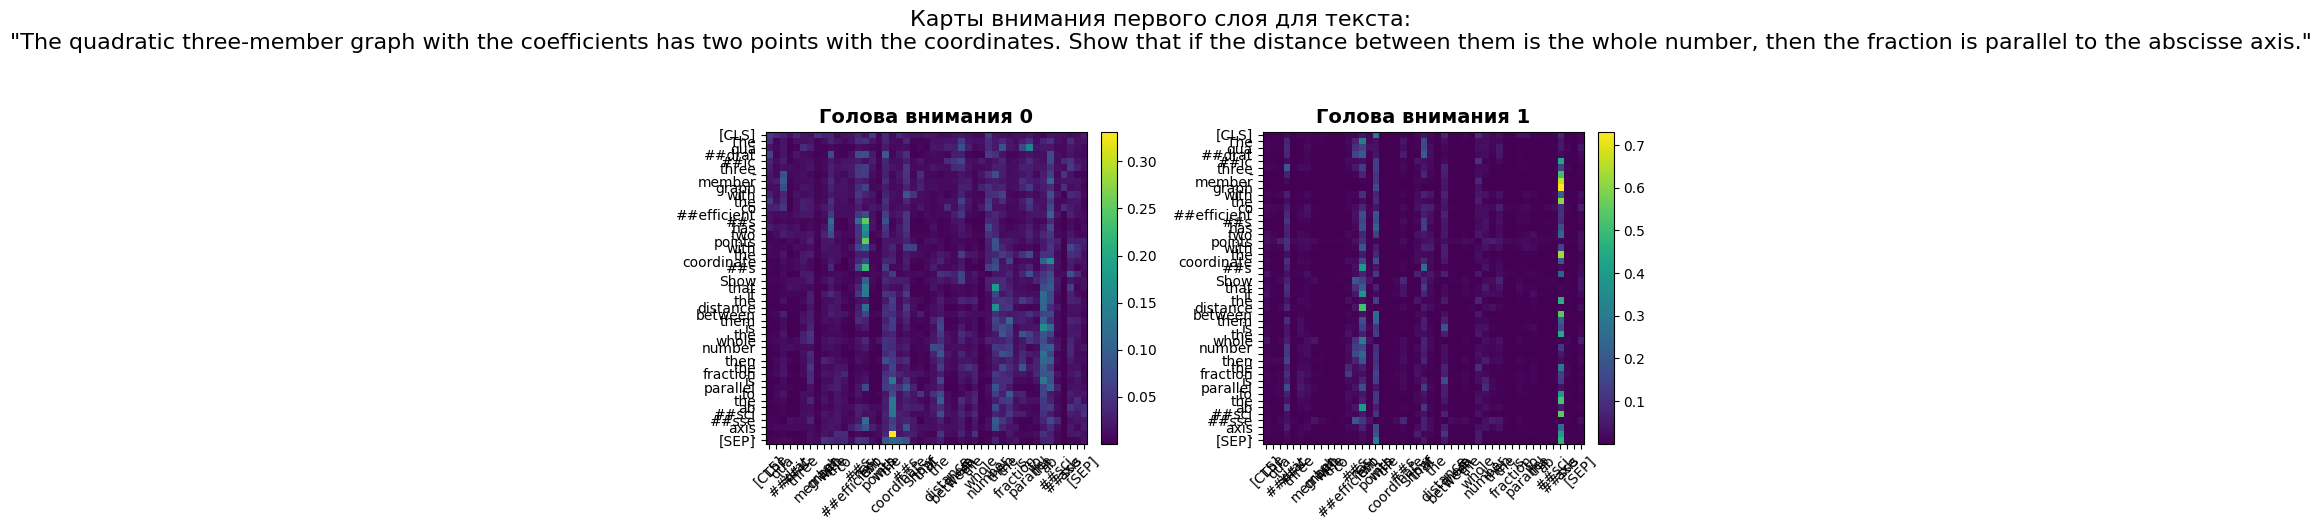

In [39]:
# с заморозкой

for i, text in enumerate(data):
  print(f"Текст {i + 1}: {text}")
  print(f"rubert-tiny2:\n")
  attention_ru_before = draw_first_layer_attention_maps(
        attention_head_ids=range(2),
        text=text,
        model=rubert_tiny_finetuned_with_freezed_backbone
    )

  print(f"MathBert:\n")
  attention_mathbert_before = draw_first_layer_attention_maps(
      attention_head_ids=range(2),
      text=text,
      model=tbs17_MathBert_finetuned_with_freezed_backbone
  )

Изменения на картинках есть, но достаточно минимальные. Ключевое - детали. Модели стали лучше видеть детали, обращать внимания на мат символы типа = и т.п. В целом, это достаточно ожидаемое поведение, ибо после обучения модели научились лучше понимать математический контекст задач. И сюда же еще одна деталь - юольше изменений именно в первой модели. Я могу это свяхать с тем, что вторая изначально обучалась на математических данных, поэтому в целом уже понимала контекст и необходимость обращать внимание на мат символы, отсюда и незначительные с точки зрения внимания изменения